<a href="https://colab.research.google.com/github/shreyasgowdac-319/ML-LAB/blob/main/Lab_6_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset
try:
    iris_df = pd.read_csv('/content/iris (1) - iris (1).csv')
    print("Iris dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'iris.csv' not found. Please make sure the file is in the correct directory.")
    # Create a dummy DataFrame if the file is not found to prevent further errors
    iris_df = pd.DataFrame()

if not iris_df.empty:
    display(iris_df.head())
    display(iris_df.info())

Iris dataset loaded successfully.


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


None

In [ ]:
# Prepare the data
if not iris_df.empty:
    X_iris = iris_df.drop('species', axis=1)  # Features
    y_iris = iris_df['species']  # Target

    # Split the data into training and testing sets (80% train, 20% test)
    X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
        X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
    )

    print("Data split for Iris dataset:")
    print(f"X_train_iris shape: {X_train_iris.shape}")
    print(f"X_test_iris shape: {X_test_iris.shape}")
    print(f"y_train_iris shape: {y_train_iris.shape}")
    print(f"y_test_iris shape: {y_test_iris.shape}")
else:
    print("Iris DataFrame is empty. Cannot proceed with data preparation.")

Data split for Iris dataset:
X_train_iris shape: (120, 4)
X_test_iris shape: (30, 4)
y_train_iris shape: (120,)
y_test_iris shape: (30,)


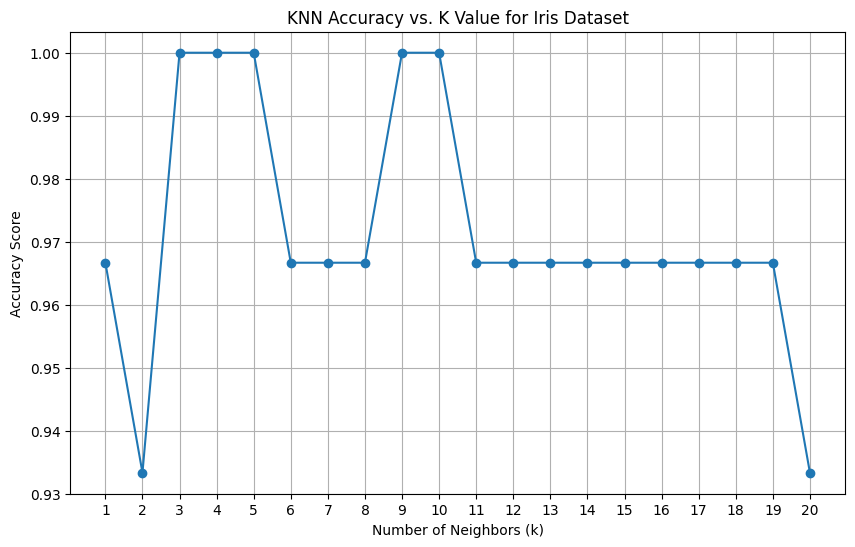

Optimal k for Iris dataset: 3

Accuracy Score (Iris): 1.0000

Confusion Matrix (Iris):


,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,10,0
virginica,0,0,10


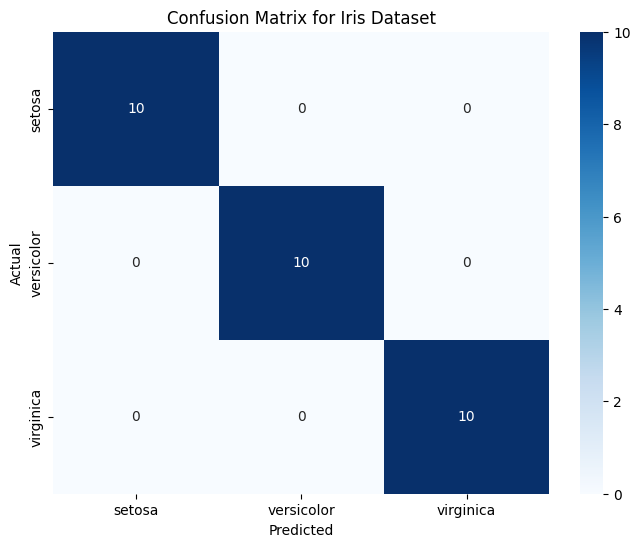


Classification Report (Iris):
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
# Choose an appropriate k value (by testing a range of k values)
if 'X_train_iris' in locals() and not X_train_iris.empty:
    k_values = range(1, 21) # Test k from 1 to 20
    accuracies = []

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_iris, y_train_iris)
        y_pred = knn.predict(X_test_iris)
        accuracies.append(accuracy_score(y_test_iris, y_pred))

    # Plotting the accuracy for different k values
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, accuracies, marker='o', linestyle='-')
    plt.title('KNN Accuracy vs. K Value for Iris Dataset')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Accuracy Score')
    plt.xticks(list(k_values))
    plt.grid(True)
    plt.show()

    # Choose the k with the highest accuracy
    optimal_k_iris = k_values[accuracies.index(max(accuracies))]
    print(f"Optimal k for Iris dataset: {optimal_k_iris}")

    # Build and train the KNN classifier with the chosen k
    knn_iris = KNeighborsClassifier(n_neighbors=optimal_k_iris)
    knn_iris.fit(X_train_iris, y_train_iris)

    # Predict on the test data
    y_pred_iris = knn_iris.predict(X_test_iris)

    # Display accuracy score
    accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)
    print(f"\nAccuracy Score (Iris): {accuracy_iris:.4f}")

    # Display confusion matrix
    cm_iris = confusion_matrix(y_test_iris, y_pred_iris)
    print("\nConfusion Matrix (Iris):")
    display(pd.DataFrame(cm_iris, index=knn_iris.classes_, columns=knn_iris.classes_))

    # Plotting the Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_iris, annot=True, fmt='d', cmap='Blues',
                xticklabels=knn_iris.classes_, yticklabels=knn_iris.classes_)
    plt.title('Confusion Matrix for Iris Dataset')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Display classification report
    class_report_iris = classification_report(y_test_iris, y_pred_iris)
    print("\nClassification Report (Iris):\n", class_report_iris)
else:
    print("Iris training data is not available. Skipping KNN for Iris.")

In [ ]:
from sklearn.preprocessing import StandardScaler

# Load the Diabetes dataset
try:
    diabetes_df = pd.read_csv('/content/diabetes - diabetes.csv')
    print("\nDiabetes dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'diabetes.csv' not found. Please make sure the file is in the correct directory.")
    diabetes_df = pd.DataFrame()

if not diabetes_df.empty:
    display(diabetes_df.head())
    display(diabetes_df.info())


Diabetes dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

In [ ]:
# Prepare the data
if not diabetes_df.empty:
    # Assuming the last column is the target variable (Outcome)
    X_diabetes = diabetes_df.drop(diabetes_df.columns[-1], axis=1) # Features
    y_diabetes = diabetes_df[diabetes_df.columns[-1]] # Target

    # Split the data into training and testing sets (80% train, 20% test)
    X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
        X_diabetes, y_diabetes, test_size=0.2, random_state=42, stratify=y_diabetes
    )

    print("\nData split for Diabetes dataset:")
    print(f"X_train_diabetes shape: {X_train_diabetes.shape}")
    print(f"X_test_diabetes shape: {X_test_diabetes.shape}")
    print(f"y_train_diabetes shape: {y_train_diabetes.shape}")
    print(f"y_test_diabetes shape: {y_test_diabetes.shape}")

    # Perform Feature Scaling
    scaler = StandardScaler()
    X_train_scaled_diabetes = scaler.fit_transform(X_train_diabetes)
    X_test_scaled_diabetes = scaler.transform(X_test_diabetes)
    print("\nFeature scaling applied to Diabetes dataset.")
else:
    print("Diabetes DataFrame is empty. Cannot proceed with data preparation.")


Data split for Diabetes dataset:
X_train_diabetes shape: (614, 8)
X_test_diabetes shape: (154, 8)
y_train_diabetes shape: (614,)
y_test_diabetes shape: (154,)

Feature scaling applied to Diabetes dataset.


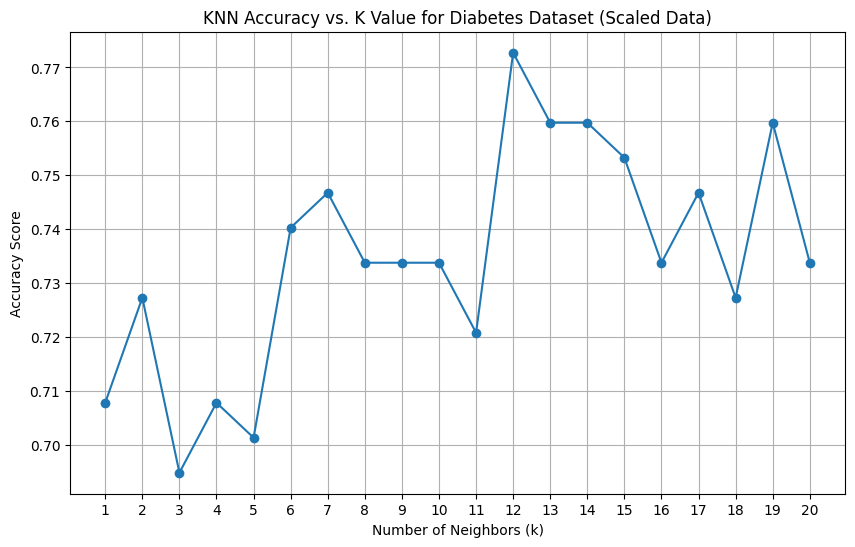

Optimal k for Diabetes dataset: 12

Accuracy Score (Diabetes): 0.7727

Confusion Matrix (Diabetes):


,Non-Diabetic,Diabetic
Non-Diabetic,88,12
Diabetic,23,31


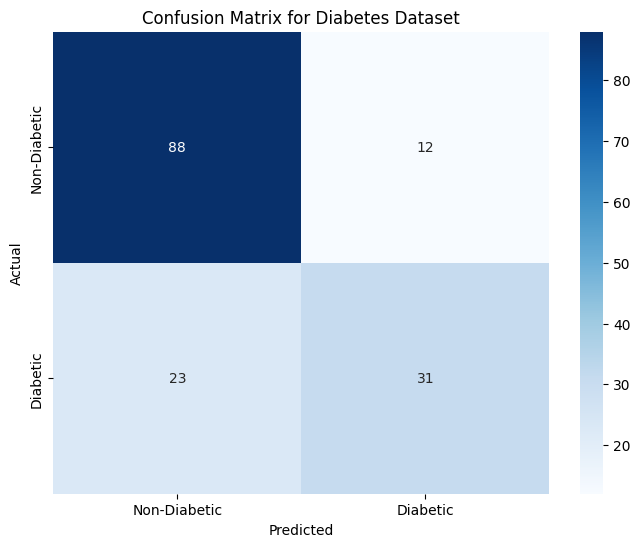

In [ ]:

if 'X_train_scaled_diabetes' in locals() and X_train_scaled_diabetes.shape[0] > 0:
    k_values_diabetes = range(1, 21)
    accuracies_diabetes = []

    for k in k_values_diabetes:
        knn_d = KNeighborsClassifier(n_neighbors=k)
        knn_d.fit(X_train_scaled_diabetes, y_train_diabetes)
        y_pred_d = knn_d.predict(X_test_scaled_diabetes)
        accuracies_diabetes.append(accuracy_score(y_test_diabetes, y_pred_d))


    plt.figure(figsize=(10, 6))
    plt.plot(k_values_diabetes, accuracies_diabetes, marker='o', linestyle='-')
    plt.title('KNN Accuracy vs. K Value for Diabetes Dataset (Scaled Data)')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Accuracy Score')
    plt.xticks(list(k_values_diabetes))
    plt.grid(True)
    plt.show()

    optimal_k_diabetes = k_values_diabetes[accuracies_diabetes.index(max(accuracies_diabetes))]
    print(f"Optimal k for Diabetes dataset: {optimal_k_diabetes}")

    knn_diabetes = KNeighborsClassifier(n_neighbors=optimal_k_diabetes)
    knn_diabetes.fit(X_train_scaled_diabetes, y_train_diabetes)

    y_pred_diabetes = knn_diabetes.predict(X_test_scaled_diabetes)

    accuracy_diabetes = accuracy_score(y_test_diabetes, y_pred_diabetes)
    print(f"\nAccuracy Score (Diabetes): {accuracy_diabetes:.4f}")

    cm_diabetes = confusion_matrix(y_test_diabetes, y_pred_diabetes)
    print("\nConfusion Matrix (Diabetes):")
    display(pd.DataFrame(cm_diabetes, index=['Non-Diabetic', 'Diabetic'], columns=['Non-Diabetic', 'Diabetic']))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_diabetes, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Diabetic', 'Diabetic'], yticklabels=['Non-Diabetic', 'Diabetic'])
    plt.title('Confusion Matrix for Diabetes Dataset')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
else:
    print("Diabetes scaled training data is not available. Skipping KNN for Diabetes.")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Heart dataset
try:
    heart_df = pd.read_csv('/content/heart - heart.csv')
    print("\nHeart dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'heart.csv' not found. Please make sure the file is in the correct directory.")
    heart_df = pd.DataFrame()

if not heart_df.empty:
    display(heart_df.head())
    display(heart_df.info())


Heart dataset loaded successfully.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


None

In [ ]:
# Prepare the data
if not heart_df.empty:
    # Assuming 'target' is the target variable
    X_heart = heart_df.drop('target', axis=1)  # Features
    y_heart = heart_df['target']  # Target

    # Split the data into training and testing sets (80% train, 20% test)
    X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(
        X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
    )

    print("\nData split for Heart dataset:")
    print(f"X_train_heart shape: {X_train_heart.shape}")
    print(f"X_test_heart shape: {X_test_heart.shape}")
    print(f"y_train_heart shape: {y_train_heart.shape}")
    print(f"y_test_heart shape: {y_test_heart.shape}")

    # Perform Feature Scaling
    scaler_heart = StandardScaler()
    X_train_scaled_heart = scaler_heart.fit_transform(X_train_heart)
    X_test_scaled_heart = scaler_heart.transform(X_test_heart)
    print("\nFeature scaling applied to Heart dataset.")
else:
    print("Heart DataFrame is empty. Cannot proceed with data preparation.")


Data split for Heart dataset:
X_train_heart shape: (242, 13)
X_test_heart shape: (61, 13)
y_train_heart shape: (242,)
y_test_heart shape: (61,)

Feature scaling applied to Heart dataset.


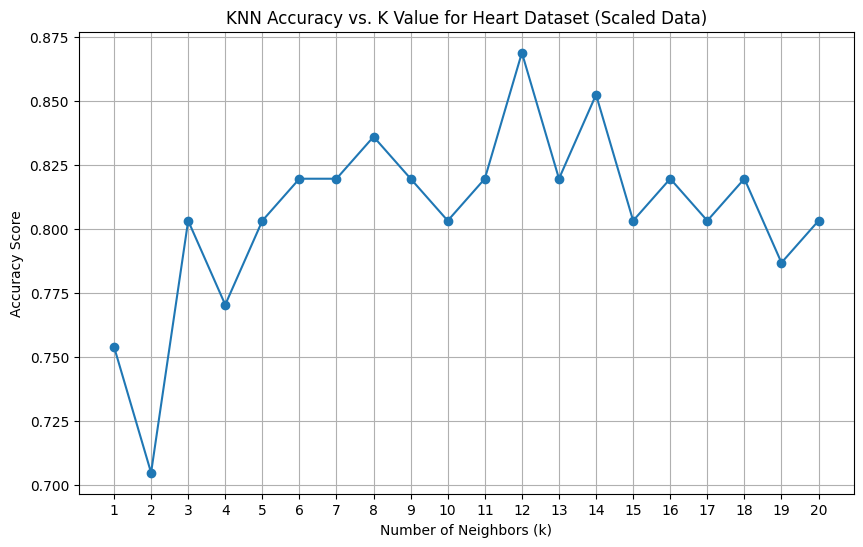

Optimal k for Heart dataset: 12

Accuracy Score (Heart): 0.8689

Confusion Matrix (Heart):


,No Disease,Disease
No Disease,22,6
Disease,2,31


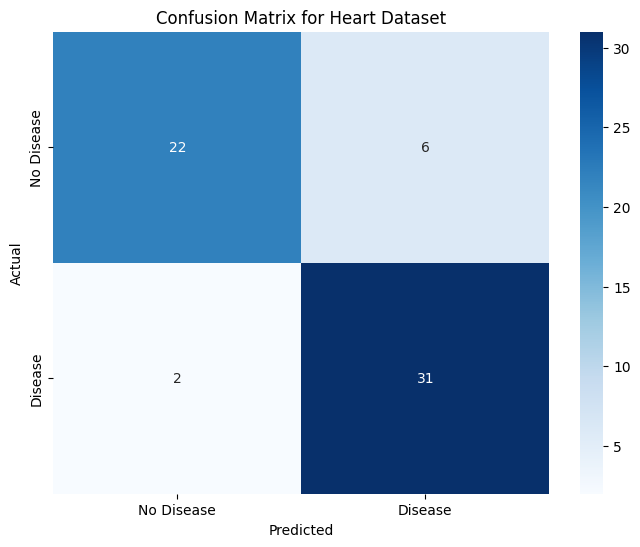


Classification Report (Heart):
               precision    recall  f1-score   support

           0       0.92      0.79      0.85        28
           1       0.84      0.94      0.89        33

    accuracy                           0.87        61
   macro avg       0.88      0.86      0.87        61
weighted avg       0.87      0.87      0.87        61



In [ ]:
# Choose an appropriate k value for Heart (by testing a range of k values)
if 'X_train_scaled_heart' in locals() and X_train_scaled_heart.shape[0] > 0:
    k_values_heart = range(1, 21)
    accuracies_heart = []

    for k in k_values_heart:
        knn_h = KNeighborsClassifier(n_neighbors=k)
        knn_h.fit(X_train_scaled_heart, y_train_heart)
        y_pred_h = knn_h.predict(X_test_scaled_heart)
        accuracies_heart.append(accuracy_score(y_test_heart, y_pred_h))

    # Plotting the accuracy for different k values
    plt.figure(figsize=(10, 6))
    plt.plot(k_values_heart, accuracies_heart, marker='o', linestyle='-')
    plt.title('KNN Accuracy vs. K Value for Heart Dataset (Scaled Data)')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Accuracy Score')
    plt.xticks(list(k_values_heart))
    plt.grid(True)
    plt.show()

    # Choose the k with the highest accuracy
    optimal_k_heart = k_values_heart[accuracies_heart.index(max(accuracies_heart))]
    print(f"Optimal k for Heart dataset: {optimal_k_heart}")

    # Build and train the KNN classifier with the chosen k on scaled data
    knn_heart = KNeighborsClassifier(n_neighbors=optimal_k_heart)
    knn_heart.fit(X_train_scaled_heart, y_train_heart)

    # Predict on the test data
    y_pred_heart = knn_heart.predict(X_test_scaled_heart)

    # Display accuracy score
    accuracy_heart = accuracy_score(y_test_heart, y_pred_heart)
    print(f"\nAccuracy Score (Heart): {accuracy_heart:.4f}")

    # Display confusion matrix
    cm_heart = confusion_matrix(y_test_heart, y_pred_heart)
    print("\nConfusion Matrix (Heart):")
    # Assuming binary classification for heart disease (0=No Disease, 1=Disease)
    display(pd.DataFrame(cm_heart, index=['No Disease', 'Disease'], columns=['No Disease', 'Disease']))

    # Plotting the Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_heart, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
    plt.title('Confusion Matrix for Heart Dataset')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Display classification report
    class_report_heart = classification_report(y_test_heart, y_pred_heart)
    print("\nClassification Report (Heart):\n", class_report_heart)
else:
    print("Heart scaled training data is not available. Skipping KNN for Heart.")